In [1]:
!pip install vadersentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud, STOPWORDS

In [30]:
df = pd.read_csv("drugsComTrain_raw.csv")
df

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79


In [31]:
# first five rows of dataset
df.head()


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [32]:
# Last rows of dataset
df.tail()

,uniqueID,drugName,condition,review,rating,date,usefulCount
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adu...",9,13-Dec-14,116


In [33]:
# Total counts of rows and columns
df.shape

(161297, 7)

In [34]:
# Information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [35]:
# Statistical information of dataset
df.describe()

,uniqueID,rating,usefulCount
count,161297.000000,161297.000000,161297.000000
mean,115923.585305,6.994377,28.004755
std,67004.445170,3.272329,36.403742
min,2.000000,1.000000,0.000000
25%,58063.000000,5.000000,6.000000
50%,115744.000000,8.000000,16.000000
75%,173776.000000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [36]:
# column names
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

STARTING DRUG ADVERSE EVENT PIPELINE
Loading data from drugsComTrain_raw.csv
Shape: (15000, 8)

Columns: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount', 'review_clean']

Missing Values:
 uniqueID         0
drugName         0
condition       86
review           0
rating           0
date             0
usefulCount      0
review_clean     0
dtype: int64

Unique Drugs: 1708

 Performing EDA 


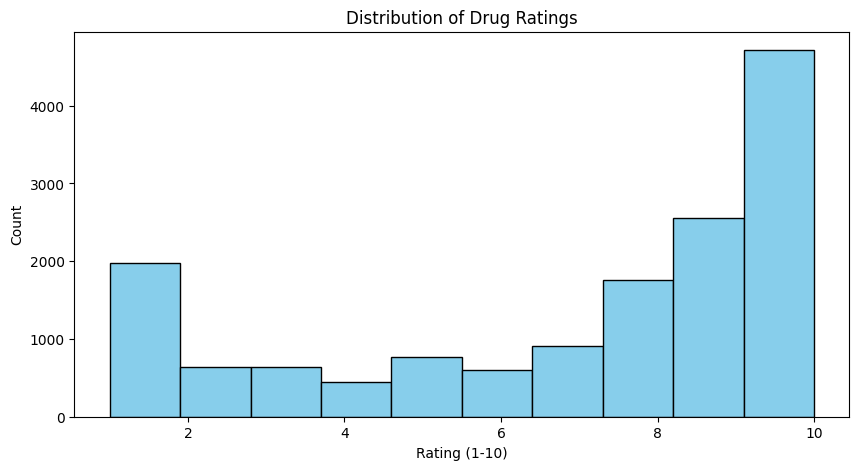

<Figure size 640x480 with 0 Axes>

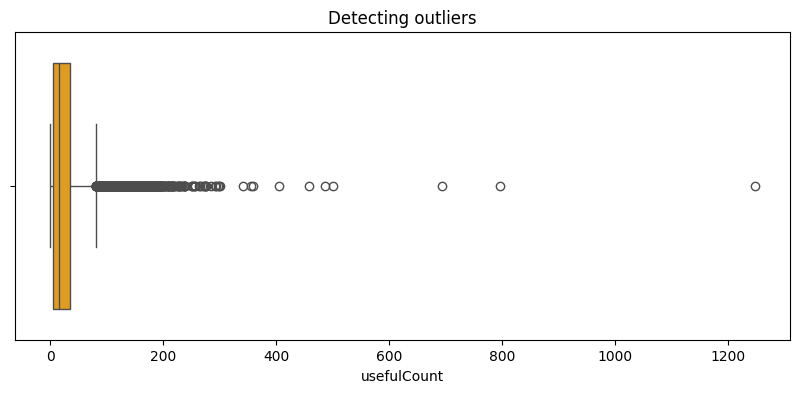

<Figure size 640x480 with 0 Axes>

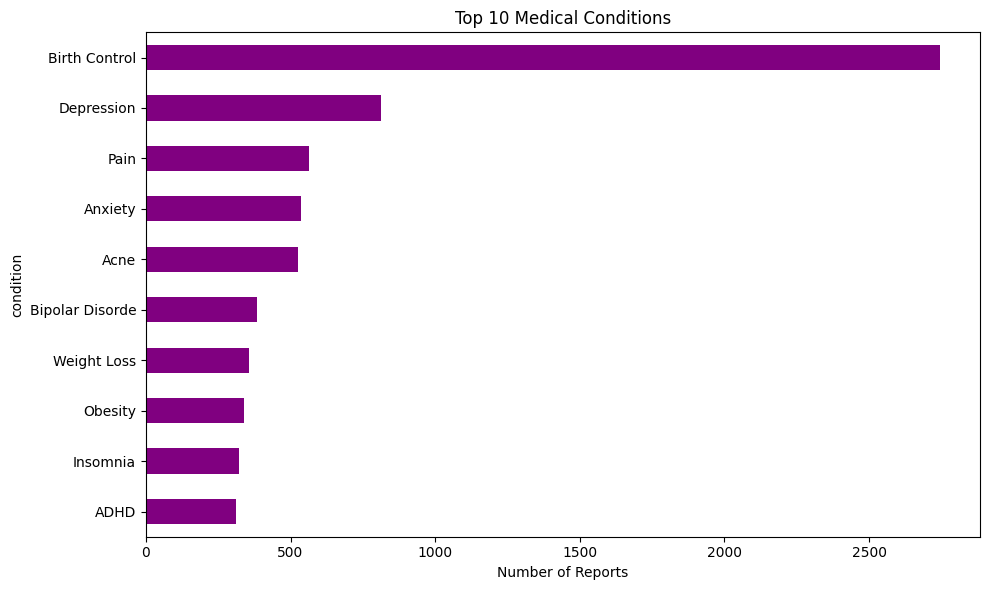


Engineering NLP Features

Training Anomaly Detection Model

Model Evaluation & Pattern Analysis
Total Anomalies Detected: 750


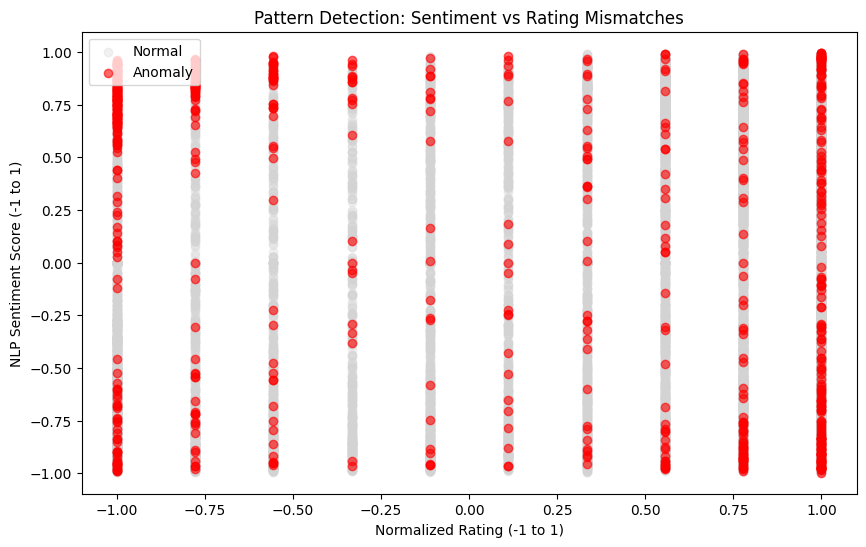


 Example Anomalous Reports

Drug: Silenor | Rating: 10
Review Snippet: "I couldn't stay asleep, tried Lunesta and Ambien, they had side effects I couldn't tolerate.  Sleep center said I had mild apnea and said their monit...

Drug: BuSpar | Rating: 9
Review Snippet: "Been on this medication for over 12 years.  Works well for me. Calms me down without the "brain zapping" I got from Paxil and Lexapro. Dosage has bee...

Drug: Implanon | Rating: 3
Review Snippet: "I have had the Implanon since May of 2009. I liked it at first, no problems. But, it is now 2 and a half years later, my periods usually last 3-4 wee...

 Visualizing Anomaly Patterns


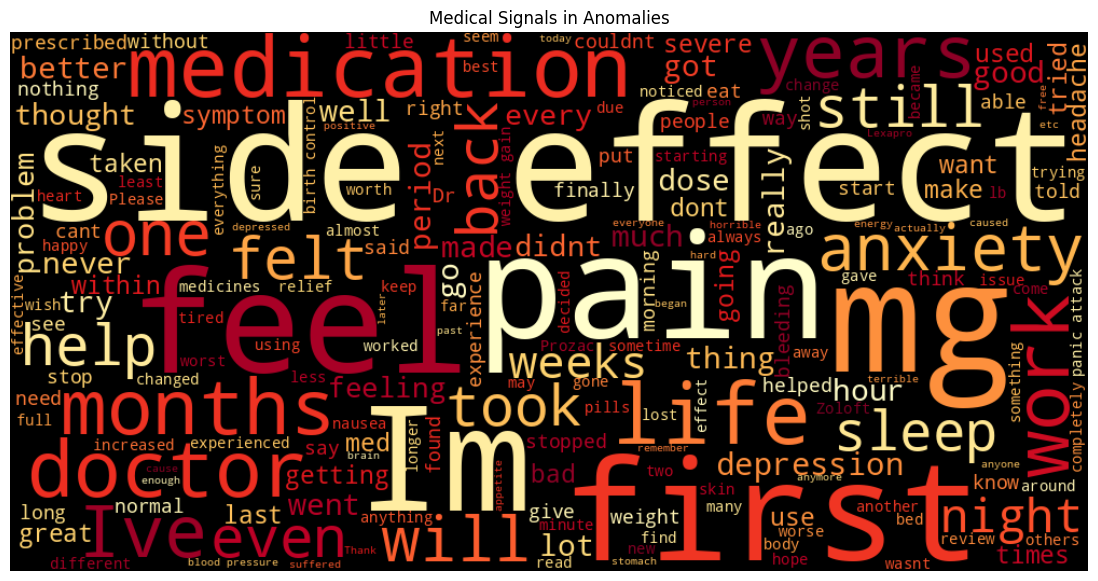


 PIPELINE COMPLETED SUCCESSFULLY


In [45]:

# CONSTANTS
FILE_PATH = 'drugsComTrain_raw.csv'
CONTAMINATION = 0.05
RANDOM_STATE = 42

def load_data(path):
    print(f"Loading data from {path}")
    df = pd.read_csv(path).sample(15000, random_state=RANDOM_STATE)
    df['review'] = df['review'].apply(html.unescape)
    # Remove special characters
    df['review_clean'] = df['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s.,!]', '', x))

    return df

# DATA OVERVIEW
def data_overview(df):
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nUnique Drugs:", df['drugName'].nunique())

# EDA
def perform_eda(df):
    print("\n Performing EDA ")

    plt.figure(figsize=(10, 5))
    plt.hist(df['rating'], bins=10, color='skyblue', edgecolor='black')
    plt.title("Distribution of Drug Ratings")
    plt.xlabel("Rating (1-10)")
    plt.ylabel("Count")
    plt.show()
    plt.tight_layout()


    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df['usefulCount'], color='orange')
    plt.title("Detecting outliers")
    plt.show()
    plt.tight_layout()


    plt.figure(figsize=(10, 6))
    df['condition'].value_counts().head(10).plot(kind='barh', color='purple')
    plt.title("Top 10 Medical Conditions")
    plt.xlabel("Number of Reports")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# NLP FEATURE ENGINEERING
def engineer_nlp_features(df):
    print("\nEngineering NLP Features")
    analyzer = SentimentIntensityAnalyzer()

    df['sentiment_score'] = df['review_clean'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
    df['normalized_rating'] = ((df['rating'] - 1) / (10 - 1)) * 2 - 1
    df['mismatch_score'] = np.abs(df['normalized_rating'] - df['sentiment_score'])

    return df

# ANOMALY DETECTION MODEL
def train_anomaly_model(df):
    print("\nTraining Anomaly Detection Model")

    features = ['sentiment_score', 'normalized_rating', 'mismatch_score', 'usefulCount']
    X = df[features].fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=100,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE
    )

    df['anomaly_label'] = model.fit_predict(X_scaled)
    df['anomaly_score'] = model.decision_function(X_scaled)

    return df

# EVALUATION AND VISUALIZATION
def evaluate_and_visualize(df):
    print("\nModel Evaluation & Pattern Analysis")

    anomalies = df[df['anomaly_label'] == -1]
    print(f"Total Anomalies Detected: {len(anomalies)}")

    plt.figure(figsize=(10, 6))
    plt.scatter(df[df['anomaly_label'] == 1]['normalized_rating'],
                df[df['anomaly_label'] == 1]['sentiment_score'],
                c='lightgrey', label='Normal', alpha=0.3)
    plt.scatter(anomalies['normalized_rating'],
                anomalies['sentiment_score'],c='red', label='Anomaly', alpha=0.6)

    plt.title("Pattern Detection: Sentiment vs Rating Mismatches")
    plt.xlabel("Normalized Rating (-1 to 1)")
    plt.ylabel("NLP Sentiment Score (-1 to 1)")
    plt.legend()
    plt.show()

    print("\n Example Anomalous Reports")
    for i, row in anomalies[['drugName', 'rating', 'review']].head(3).iterrows():
        print(f"\nDrug: {row['drugName']} | Rating: {row['rating']}")
        print(f"Review Snippet: {row['review'][:150]}...")

# PATTERN VISUALIZATION
def generate_anomaly_wordcloud(df):
    print("\n Visualizing Anomaly Patterns")

    anomaly_text = " ".join(review for review in df[df['anomaly_label'] == -1].review_clean)

    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update(["month", "now", "year", "week", "day", "days", "started", "time", "take", "taking", "medicine", "drug", "pill"])

    wordcloud = WordCloud(width=1000, height=500, background_color='black',
                          stopwords=custom_stopwords, colormap='YlOrRd').generate(anomaly_text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Medical Signals in Anomalies")
    plt.show()

# MAIN
def main():
    print("STARTING DRUG ADVERSE EVENT PIPELINE")

    df = load_data(FILE_PATH)
    data_overview(df)
    perform_eda(df)
    df = engineer_nlp_features(df)
    df = train_anomaly_model(df)
    evaluate_and_visualize(df)
    generate_anomaly_wordcloud(df)

    print("\n PIPELINE COMPLETED SUCCESSFULLY")

if __name__ == "__main__":
    main()


In [46]:
df.to_csv("drugs_cleaned.csv", index=False)